# 🩺 Chronic Kidney Disease (CKD) — Statistical Analysis

**Dataset:** Chronic Kidney Disease (CKD) Testing Dataset  
**Author:** Akmal  
**Topics Covered:**
- NumPy fundamentals (`np.array`, `np.mean`, `np.std`, `np.median`)
- Matplotlib & Seaborn visualizations (Line, Bar, Scatter, Histogram)
- Descriptive statistics: Mean, Median, Mode
- Variance & Standard Deviation with visualizations
- Distributions: Histogram, KDE plot
- Percentile, IQR, Outlier detection & Boxplot

---

> **Dataset context:** This dataset contains clinical records of 4,800 patients with various kidney disease stages: Healthy, Mild CKD (Stage 1–2), Moderate CKD (Stage 3), Severe CKD (Stage 4), and Kidney Failure (Stage 5).

## 📦 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# ── Style settings ──────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["figure.figsize"] = (10, 5)
COLORS = sns.color_palette("muted")

print("✅ All libraries imported successfully")
print(f"  NumPy  : {np.__version__}")
print(f"  Pandas : {pd.__version__}")

✅ All libraries imported successfully
  NumPy  : 2.3.5
  Pandas : 2.3.3


---
## 📂 2. Load & Explore the Dataset

In [3]:
df = pd.read_csv("CKD_dataset.csv")

print(f"Shape  : {df.shape}  →  {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nTarget classes:")
print(df["Target"].value_counts().to_string())
df.head()

Shape  : (4800, 36)  →  4800 rows × 36 columns

Target classes:
Target
Healthy Kidney              3615
Mild CKD (Stage 1–2)         575
Moderate CKD (Stage 3)       318
Severe CKD (Stage 4)         196
Kidney Failure (Stage 5)      96


,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,38,0,33,114,78,78,0,10,117,...,97,4.677411,211,203,4,5.156141,No,No,Yes,No
1,Severe CKD (Stage 4),76,0,28,166,103,92,5,84,25,...,111,9.490302,194,210,2,7.922118,No,No,No,No
2,Healthy Kidney,63,0,33,109,79,98,0,17,109,...,125,6.023745,243,138,4,6.606848,No,No,No,Yes
3,Healthy Kidney,54,0,31,107,62,109,0,10,107,...,127,5.772014,163,276,4,6.651897,No,Yes,No,Yes
4,Healthy Kidney,20,0,20,111,63,92,0,17,97,...,127,8.483288,221,264,4,6.400641,No,Yes,Yes,No


In [4]:
# Quick summary statistics via pandas
df.describe().round(2)

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,Urine_Albumin,...,WBC_Count,Platelet_Count,Packed_Cell_Volume,Blood_Glucose_Random,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein
count,4800.00,4800.00,4800.00,4800.00,4800.00,4800.00,4800.00,4800.00,4800.00,4800.00,...,4800.00,4800.00,4800.00,4800.00,4800.00,4800.00,4800.00,4800.00,4800.00,4800.00
mean,52.04,0.51,26.00,113.26,75.20,84.81,0.62,21.63,91.89,58.84,...,7466.75,299515.23,42.27,134.30,99.48,6.98,214.88,201.24,3.61,6.50
std,18.79,0.50,4.95,19.02,11.99,14.37,1.45,20.66,26.66,136.00,...,2029.81,85795.59,5.50,37.32,17.18,1.71,37.24,57.47,0.76,0.86
min,20.00,0.00,18.00,90.00,60.00,60.00,0.00,7.00,5.00,0.00,...,4000.00,150055.00,20.00,70.00,70.00,4.00,150.00,100.00,1.00,5.00
25%,36.00,0.00,22.00,100.00,66.00,72.00,0.00,11.00,90.00,6.00,...,5699.75,225576.75,40.00,102.00,85.00,5.48,183.00,152.00,4.00,5.75
50%,52.00,1.00,26.00,109.00,73.00,85.00,0.00,15.00,100.00,13.00,...,7454.00,298463.00,43.00,134.00,100.00,6.98,216.00,203.00,4.00,6.51
75%,68.25,1.00,30.00,119.00,79.00,97.00,0.00,19.00,110.00,19.00,...,9216.75,372825.25,46.00,166.00,114.00,8.44,247.00,250.00,4.00,7.25
max,84.00,1.00,34.00,189.00,119.00,109.00,9.00,149.00,119.00,997.00,...,10999.00,449965.00,49.00,199.00,129.00,10.00,279.00,299.00,4.00,8.00


In [5]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "✅ No missing values found!")

Missing values per column:
✅ No missing values found!


---
## 🔢 3. NumPy Fundamentals

We extract key clinical columns into NumPy arrays and compute core statistics.

In [6]:
# ── Extract columns as NumPy arrays ─────────────────────────────
age        = np.array(df["Age"])
egfr       = np.array(df["eGFR"])           # kidney filtration rate
creatinine = np.array(df["Serum_Creatinine"])
bmi        = np.array(df["BMI"])
hemoglobin = np.array(df["Hemoglobin"])

# ── Core NumPy statistics ────────────────────────────────────────
stats_table = {
    "Feature"  : ["Age", "eGFR", "Serum Creatinine", "BMI", "Hemoglobin"],
    "Mean"     : [np.mean(x)   for x in [age, egfr, creatinine, bmi, hemoglobin]],
    "Median"   : [np.median(x) for x in [age, egfr, creatinine, bmi, hemoglobin]],
    "Std Dev"  : [np.std(x)    for x in [age, egfr, creatinine, bmi, hemoglobin]],
    "Min"      : [np.min(x)    for x in [age, egfr, creatinine, bmi, hemoglobin]],
    "Max"      : [np.max(x)    for x in [age, egfr, creatinine, bmi, hemoglobin]],
}

pd.DataFrame(stats_table).set_index("Feature").round(2)

,Mean,Median,Std Dev,Min,Max
Feature,,,,,
Age,52.04,52.0,18.79,20,84
eGFR,91.89,100.0,26.66,5,119
Serum Creatinine,0.62,0.0,1.45,0,9
BMI,26.00,26.0,4.95,18,34
Hemoglobin,13.45,14.0,2.30,5,16


### 📈 3.1 — Line Plot: Patient Age Profile Across Dataset

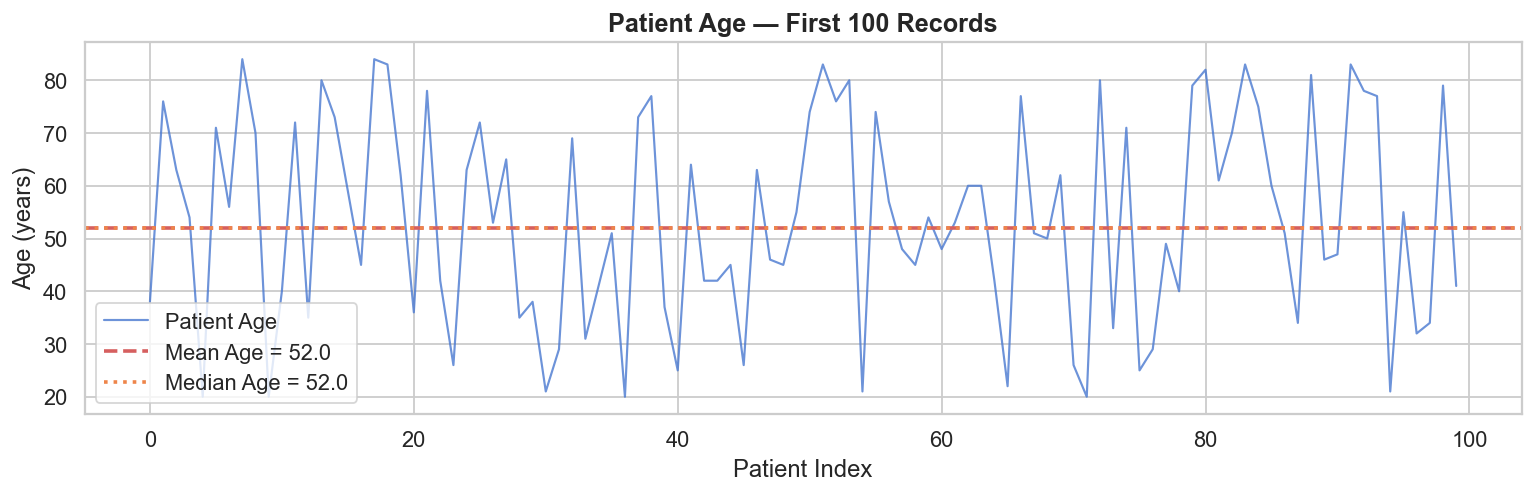

In [7]:
# Show age values for the first 100 patients with mean line
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(age[:100], color=COLORS[0], linewidth=1.2, alpha=0.8, label="Patient Age")
ax.axhline(np.mean(age), color=COLORS[3], linewidth=2, linestyle="--",
           label=f"Mean Age = {np.mean(age):.1f}")
ax.axhline(np.median(age), color=COLORS[1], linewidth=2, linestyle=":",
           label=f"Median Age = {np.median(age):.1f}")

ax.set_title("Patient Age — First 100 Records", fontsize=14, fontweight="bold")
ax.set_xlabel("Patient Index")
ax.set_ylabel("Age (years)")
ax.legend()

plt.tight_layout()
plt.savefig("plots/01_line_age_profile.png", bbox_inches="tight")
plt.show()

---
## 📊 4. Descriptive Statistics: Mean, Median, Mode

> **Mean** = average value  
> **Median** = middle value (robust to outliers)  
> **Mode** = most frequently occurring value

In [8]:
features = {
    "Age"             : age,
    "eGFR"            : egfr,
    "Serum Creatinine" : creatinine,
    "BMI"             : bmi,
    "Hemoglobin"      : hemoglobin,
}

print(f"{'Feature':<20} {'Mean':>8} {'Median':>8} {'Mode':>8}")
print("-" * 48)
for name, arr in features.items():
    mode_val = stats.mode(arr, keepdims=True).mode[0]
    print(f"{name:<20} {np.mean(arr):>8.2f} {np.median(arr):>8.2f} {mode_val:>8.2f}")

Feature                  Mean   Median     Mode
------------------------------------------------
Age                     52.04    52.00    45.00
eGFR                    91.89   100.00   116.00
Serum Creatinine         0.62     0.00     0.00
BMI                     26.00    26.00    32.00
Hemoglobin              13.45    14.00    13.00


### 📊 4.1 — Bar Chart: Mean Values of Clinical Features

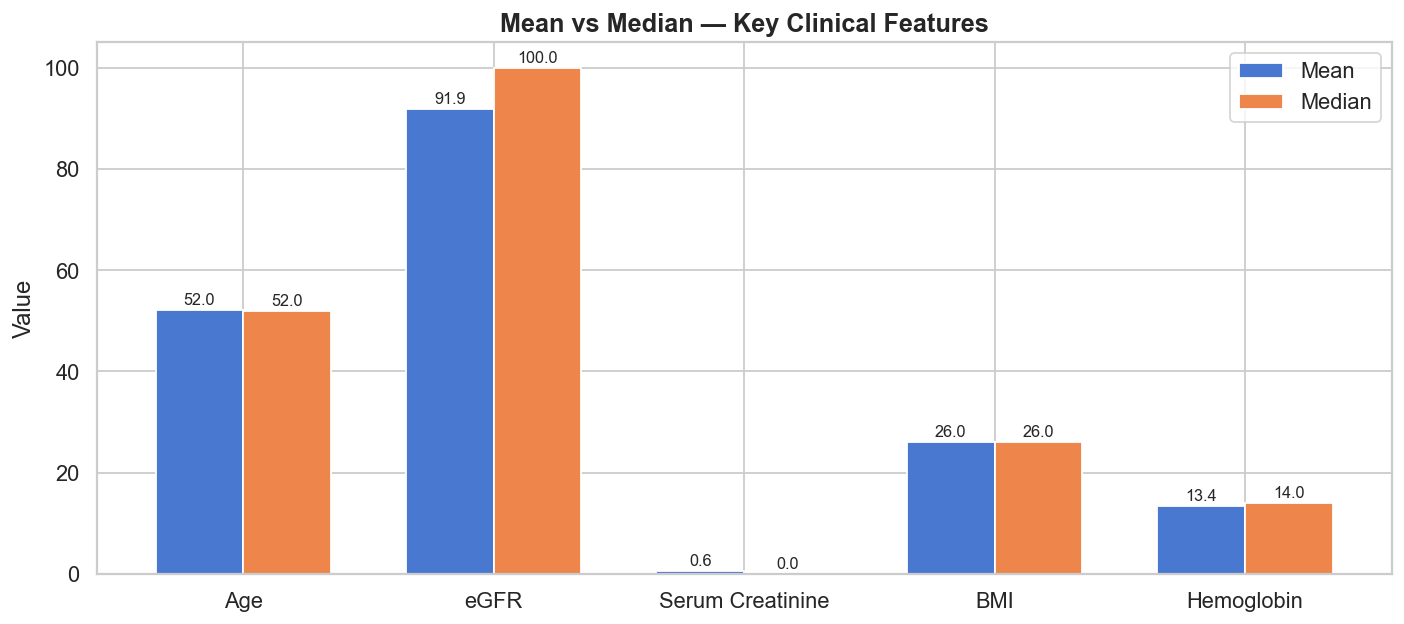

In [9]:
feature_names = list(features.keys())
means   = [np.mean(arr)   for arr in features.values()]
medians = [np.median(arr) for arr in features.values()]

x = np.arange(len(feature_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, means,   width, label="Mean",   color=COLORS[0], edgecolor="white")
bars2 = ax.bar(x + width/2, medians, width, label="Median", color=COLORS[1], edgecolor="white")

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(feature_names)
ax.set_title("Mean vs Median — Key Clinical Features", fontsize=14, fontweight="bold")
ax.set_ylabel("Value")
ax.legend()

plt.tight_layout()
plt.savefig("plots/02_bar_mean_median.png", bbox_inches="tight")
plt.show()

### 🔵 4.2 — Scatter Plot: Age vs eGFR (kidney function indicator)

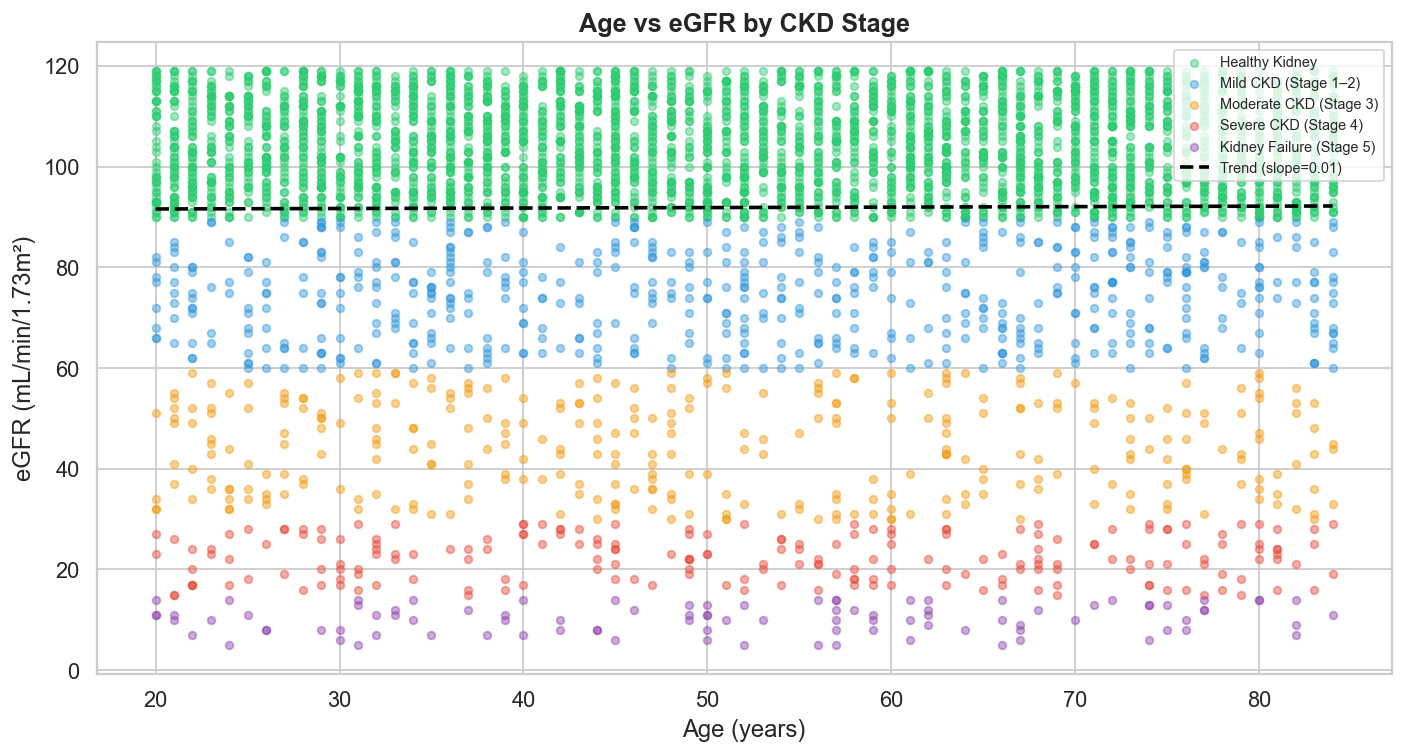

📌 Pearson correlation (Age ↔ eGFR): 0.007


In [11]:
# Color-code points by CKD stage
stage_palette = {
    "Healthy Kidney"       : "#2ecc71",
    "Mild CKD (Stage 1–2)" : "#3498db",
    "Moderate CKD (Stage 3)": "#f39c12",
    "Severe CKD (Stage 4)" : "#e74c3c",
    "Kidney Failure (Stage 5)": "#8e44ad",
}

fig, ax = plt.subplots(figsize=(11, 6))

for stage, color in stage_palette.items():
    mask = df["Target"] == stage
    ax.scatter(df.loc[mask, "Age"], df.loc[mask, "eGFR"],
               alpha=0.45, s=18, color=color, label=stage)

# Trend line
m, b = np.polyfit(age, egfr, 1)
ax.plot(np.sort(age), m * np.sort(age) + b,
        color="black", linewidth=2, linestyle="--", label=f"Trend (slope={m:.2f})")

ax.set_title("Age vs eGFR by CKD Stage", fontsize=14, fontweight="bold")
ax.set_xlabel("Age (years)")
ax.set_ylabel("eGFR (mL/min/1.73m²)")
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("plots/03_scatter_age_egfr.png", bbox_inches="tight")
plt.show()

corr = np.corrcoef(age, egfr)[0, 1]
print(f"📌 Pearson correlation (Age ↔ eGFR): {corr:.3f}")

---
## 📉 5. Variance & Standard Deviation

> **Variance** = average squared deviation from the mean → `np.var()`  
> **Std Dev** = square root of variance → `np.std()` (same unit as data)

In [12]:
print(f"{'Feature':<20} {'Variance':>12} {'Std Dev':>10}")
print("-" * 45)
for name, arr in features.items():
    print(f"{name:<20} {np.var(arr):>12.2f} {np.std(arr):>10.2f}")

Feature                  Variance    Std Dev
---------------------------------------------
Age                        353.17      18.79
eGFR                       710.61      26.66
Serum Creatinine             2.11       1.45
BMI                         24.48       4.95
Hemoglobin                   5.31       2.30


### 📊 5.1 — Bar Chart: Std Dev Comparison Across Features

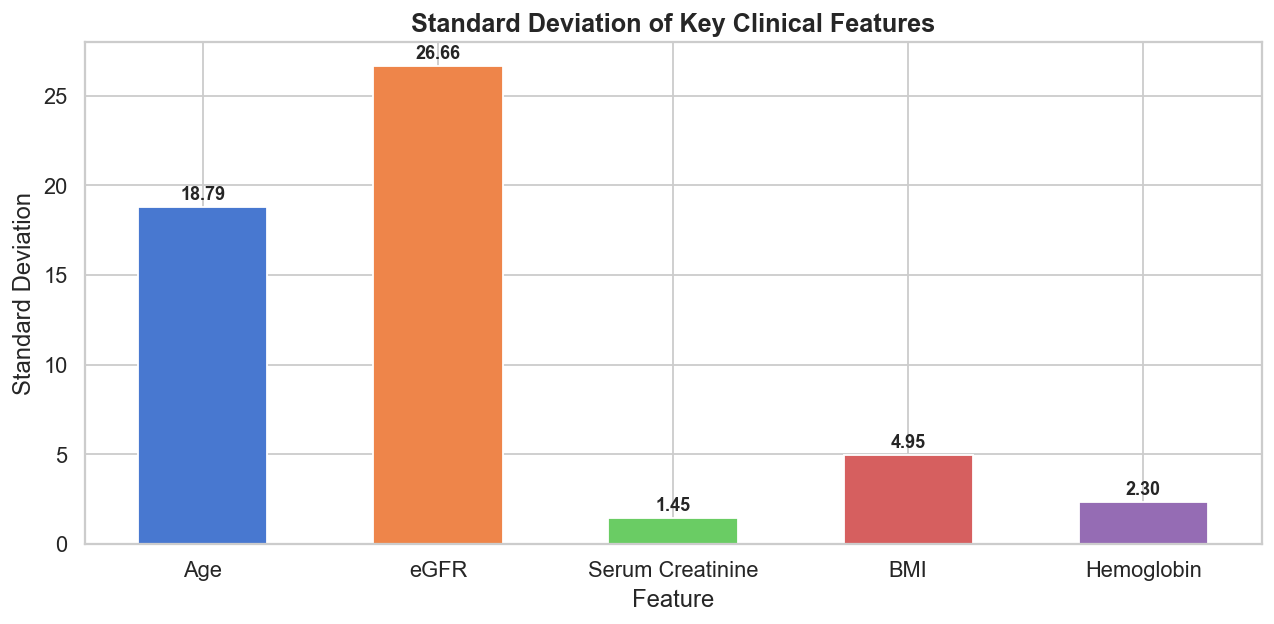

In [13]:
std_vals = [np.std(arr) for arr in features.values()]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(feature_names, std_vals, color=COLORS, edgecolor="white", width=0.55)

for bar, val in zip(bars, std_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Standard Deviation of Key Clinical Features", fontsize=14, fontweight="bold")
ax.set_ylabel("Standard Deviation")
ax.set_xlabel("Feature")

plt.tight_layout()
plt.savefig("plots/04_bar_std_dev.png", bbox_inches="tight")
plt.show()

### 📈 5.2 — Visualizing Mean ± Std Dev (Error Band)

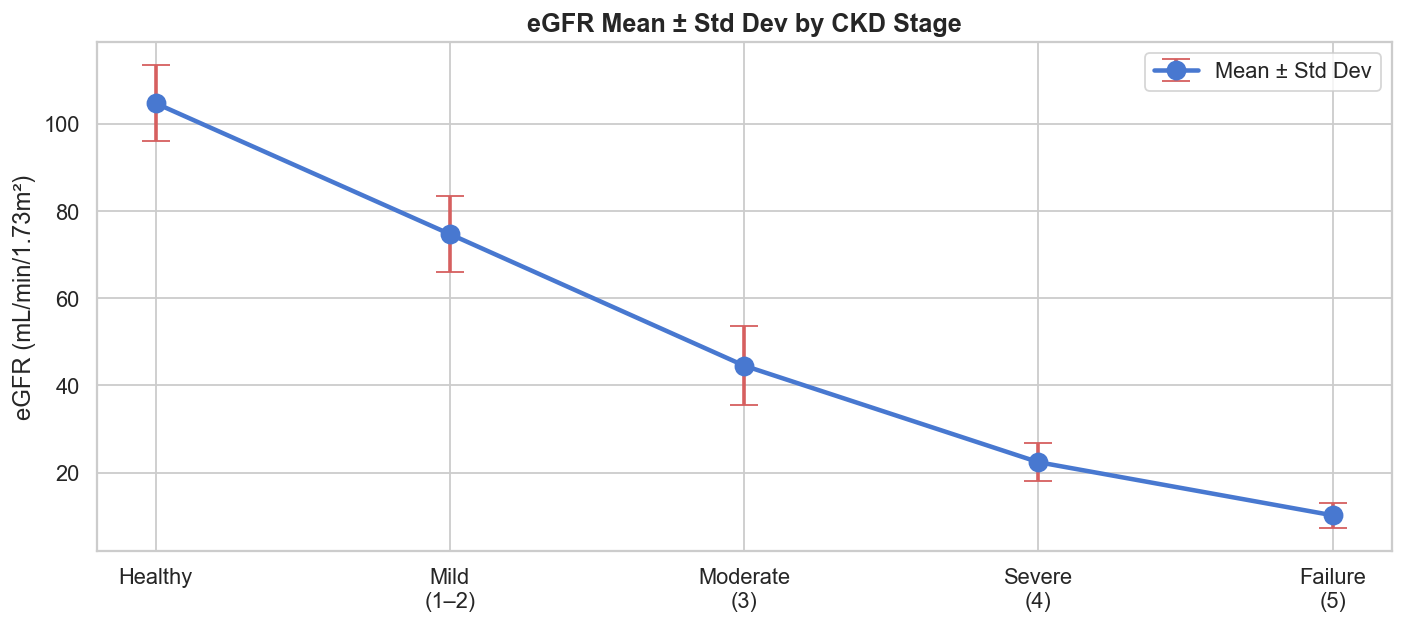

In [14]:
# eGFR mean ± std per CKD stage (ordered)
stage_order = [
    "Healthy Kidney",
    "Mild CKD (Stage 1–2)",
    "Moderate CKD (Stage 3)",
    "Severe CKD (Stage 4)",
    "Kidney Failure (Stage 5)",
]

stage_means = [df.loc[df["Target"] == s, "eGFR"].mean() for s in stage_order]
stage_stds  = [df.loc[df["Target"] == s, "eGFR"].std()  for s in stage_order]

fig, ax = plt.subplots(figsize=(11, 5))
x_pos = np.arange(len(stage_order))

ax.errorbar(x_pos, stage_means, yerr=stage_stds, fmt="o-", linewidth=2.5,
            markersize=10, capsize=8, color=COLORS[0], ecolor=COLORS[3],
            elinewidth=2, label="Mean ± Std Dev")

short_labels = ["Healthy", "Mild\n(1–2)", "Moderate\n(3)", "Severe\n(4)", "Failure\n(5)"]
ax.set_xticks(x_pos)
ax.set_xticklabels(short_labels)
ax.set_title("eGFR Mean ± Std Dev by CKD Stage", fontsize=14, fontweight="bold")
ax.set_ylabel("eGFR (mL/min/1.73m²)")
ax.legend()

plt.tight_layout()
plt.savefig("plots/05_line_egfr_std.png", bbox_inches="tight")
plt.show()

---
## 📐 6. Distributions: Histogram & KDE Plot

> **Histogram** = frequency count per bin  
> **KDE (Kernel Density Estimate)** = smooth continuous probability curve

### 6.1 — Histogram: Age Distribution

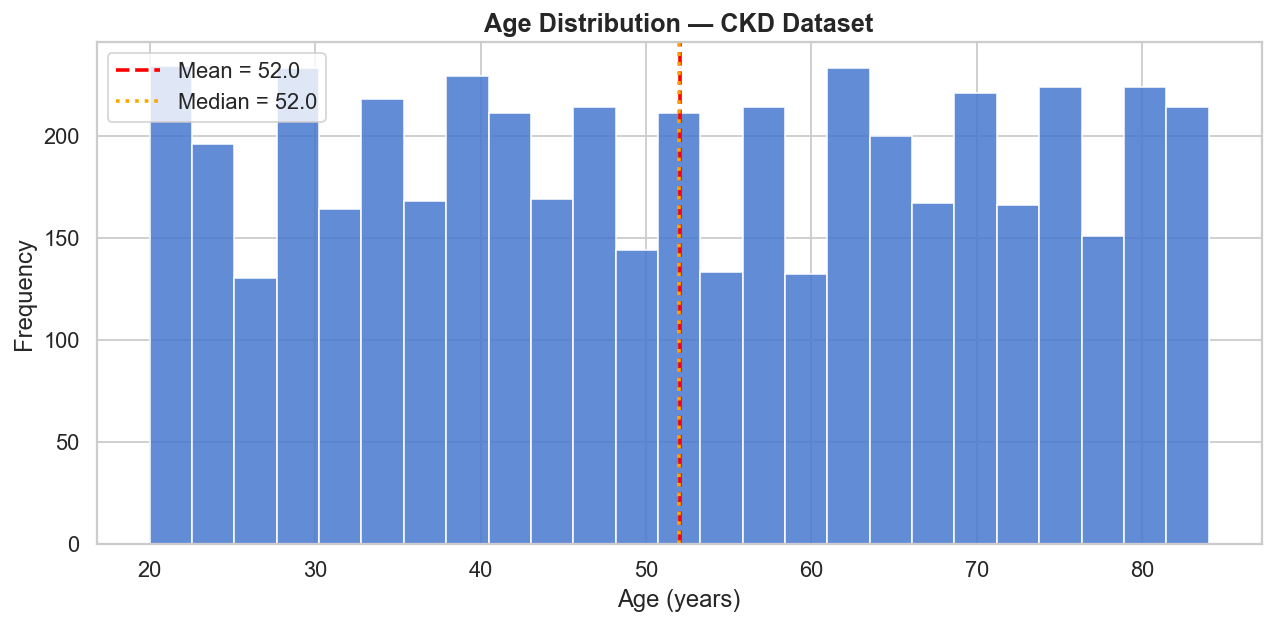

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(age, bins=25, color=COLORS[0], edgecolor="white", alpha=0.85)
ax.axvline(np.mean(age),   color="red",    linestyle="--", linewidth=2,
           label=f"Mean = {np.mean(age):.1f}")
ax.axvline(np.median(age), color="orange", linestyle=":",  linewidth=2,
           label=f"Median = {np.median(age):.1f}")

ax.set_title("Age Distribution — CKD Dataset", fontsize=14, fontweight="bold")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Frequency")
ax.legend()

plt.tight_layout()
plt.savefig("plots/06_hist_age.png", bbox_inches="tight")
plt.show()

### 6.2 — KDE Plot: eGFR Distribution by CKD Stage

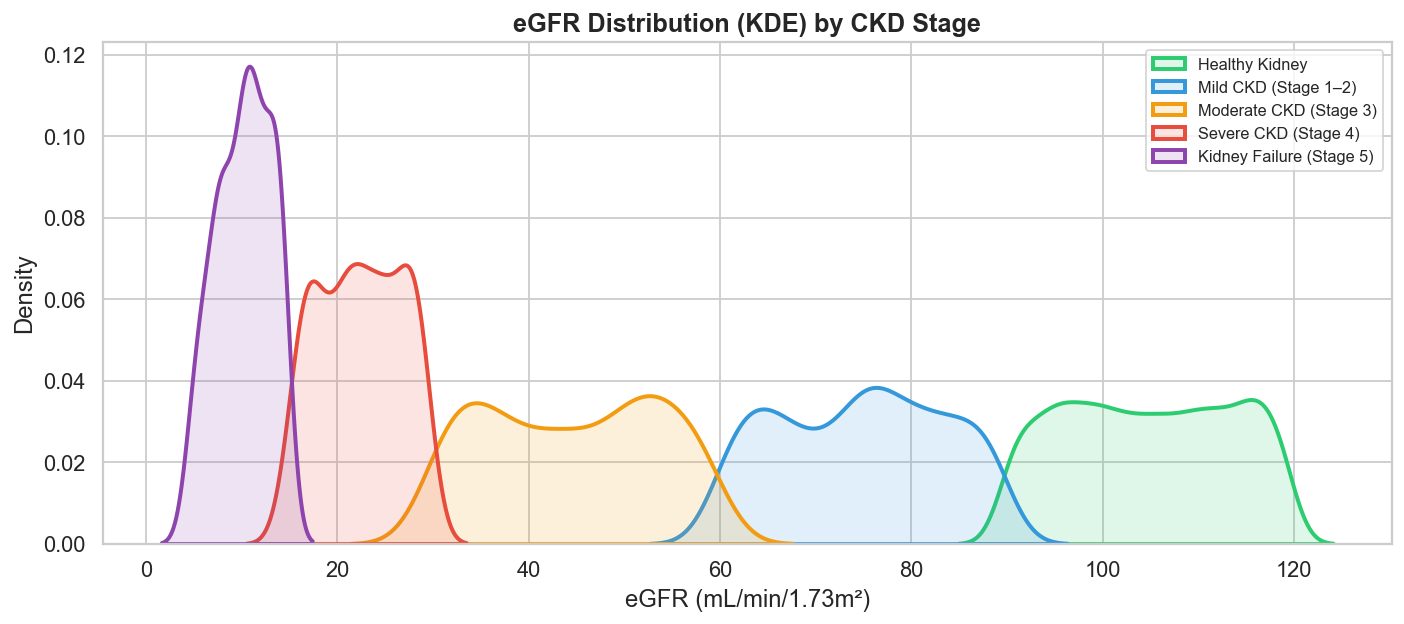

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))

for stage, color in stage_palette.items():
    subset = df.loc[df["Target"] == stage, "eGFR"]
    sns.kdeplot(subset, ax=ax, label=stage, color=color, linewidth=2.2, fill=True, alpha=0.15)

ax.set_title("eGFR Distribution (KDE) by CKD Stage", fontsize=14, fontweight="bold")
ax.set_xlabel("eGFR (mL/min/1.73m²)")
ax.set_ylabel("Density")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("plots/07_kde_egfr_stage.png", bbox_inches="tight")
plt.show()

### 6.3 — Histogram + KDE Overlay: Four Key Features

In [ ]:
plot_features = ["Age", "eGFR", "Serum_Creatinine", "BMI"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, feat in enumerate(plot_features):
    sns.histplot(df[feat], ax=axes[i], kde=True, color=COLORS[i],
                 edgecolor="white", bins=30, alpha=0.7)
    axes[i].axvline(df[feat].mean(),   color="red",    linestyle="--", linewidth=1.8,
                    label=f"Mean={df[feat].mean():.1f}")
    axes[i].axvline(df[feat].median(), color="orange", linestyle=":",  linewidth=1.8,
                    label=f"Median={df[feat].median():.1f}")
    axes[i].set_title(feat.replace("_", " "), fontweight="bold")
    axes[i].legend(fontsize=8)

fig.suptitle("Distribution (Histogram + KDE) of Key Features",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plots/08_histkde_four_features.png", bbox_inches="tight")
plt.show()

---
## 📦 7. Percentile, IQR & Outlier Detection

> **Percentile** = value below which X% of observations fall  
> **IQR (Interquartile Range)** = Q3 − Q1 (middle 50% of data)  
> **Outlier rule** = values below Q1 − 1.5×IQR  or  above Q3 + 1.5×IQR

In [18]:
def outlier_summary(arr, name):
    """Compute percentiles, IQR, fences, and count outliers."""
    q1  = np.percentile(arr, 25)
    q3  = np.percentile(arr, 75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    n_outliers = np.sum((arr < lower_fence) | (arr > upper_fence))
    pct_outliers = 100 * n_outliers / len(arr)

    print(f"── {name} ──")
    print(f"  P25={q1:.2f}  P50={np.percentile(arr,50):.2f}  P75={q3:.2f}  P90={np.percentile(arr,90):.2f}")
    print(f"  IQR={iqr:.2f}   Lower fence={lower_fence:.2f}   Upper fence={upper_fence:.2f}")
    print(f"  Outliers: {n_outliers} ({pct_outliers:.1f}%)\n")
    return {"Q1": q1, "Q3": q3, "IQR": iqr, "Lower": lower_fence,
            "Upper": upper_fence, "Outliers": n_outliers}

for name, arr in features.items():
    outlier_summary(arr, name)

── Age ──
  P25=36.00  P50=52.00  P75=68.25  P90=78.00
  IQR=32.25   Lower fence=-12.38   Upper fence=116.62
  Outliers: 0 (0.0%)

── eGFR ──
  P25=90.00  P50=100.00  P75=110.00  P90=116.00
  IQR=20.00   Lower fence=60.00   Upper fence=140.00
  Outliers: 610 (12.7%)

── Serum Creatinine ──
  P25=0.00  P50=0.00  P75=0.00  P90=2.00
  IQR=0.00   Lower fence=0.00   Upper fence=0.00
  Outliers: 1185 (24.7%)

── BMI ──
  P25=22.00  P50=26.00  P75=30.00  P90=33.00
  IQR=8.00   Lower fence=10.00   Upper fence=42.00
  Outliers: 0 (0.0%)

── Hemoglobin ──
  P25=13.00  P50=14.00  P75=15.00  P90=16.00
  IQR=2.00   Lower fence=10.00   Upper fence=18.00
  Outliers: 399 (8.3%)



### 📦 7.1 — Boxplot: All Features Side-by-Side

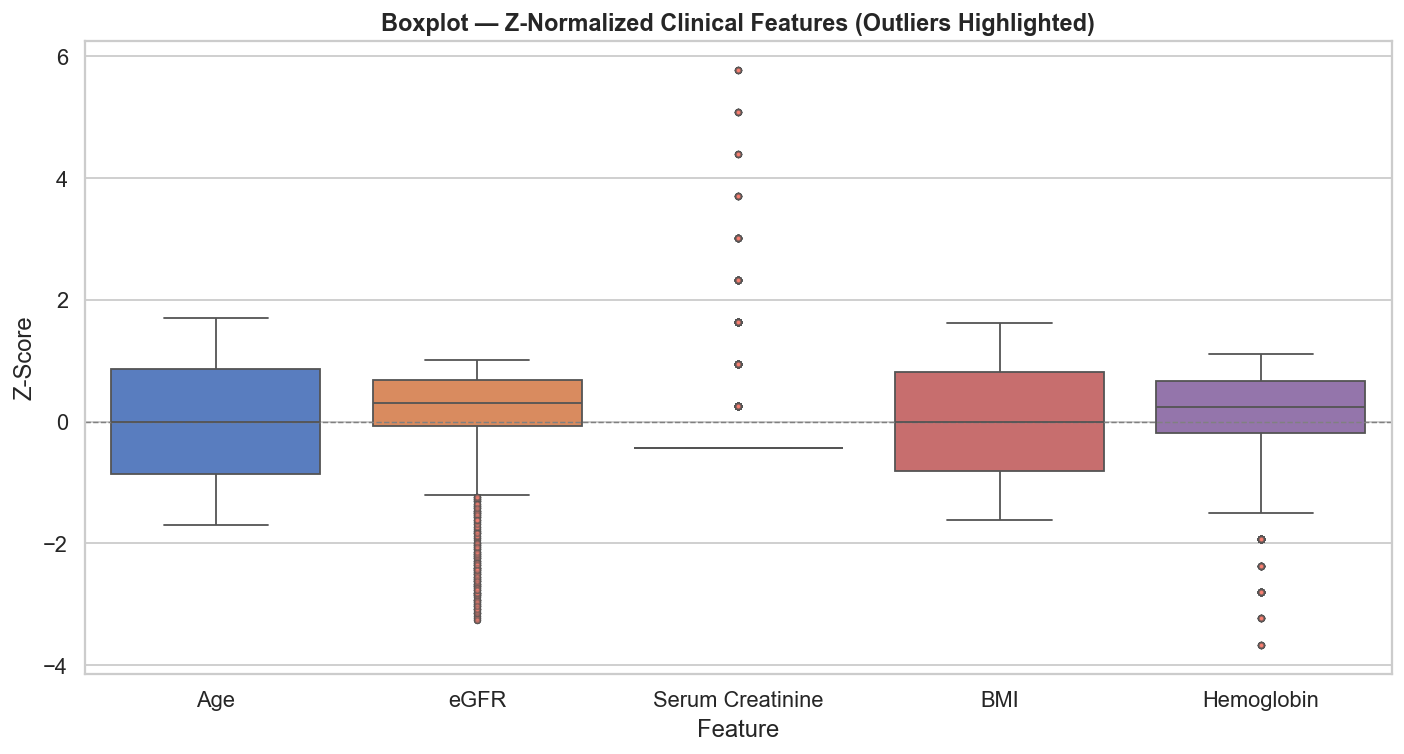

In [20]:
# Normalize to z-scores so different scales fit one plot
normalized = {name: (arr - np.mean(arr)) / np.std(arr) for name, arr in features.items()}
box_df = pd.DataFrame(normalized)

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=box_df, ax=ax, palette="muted",
            flierprops=dict(marker="o", markerfacecolor="salmon", markersize=3, alpha=0.5))

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Boxplot — Z-Normalized Clinical Features (Outliers Highlighted)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Z-Score")
ax.set_xlabel("Feature")

plt.tight_layout()
plt.savefig("plots/09_boxplot_all_features.png", bbox_inches="tight")
plt.show()

### 📦 7.2 — Boxplot: eGFR per CKD Stage

C:\Users\Akm\AppData\Local\Temp\ipykernel_12128\1258321178.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Akm\AppData\Local\Temp\ipykernel_12128\1258321178.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Healthy", "Mild\n(1–2)", "Moderate\n(3)", "Severe\n(4)", "Failure\n(5)"])


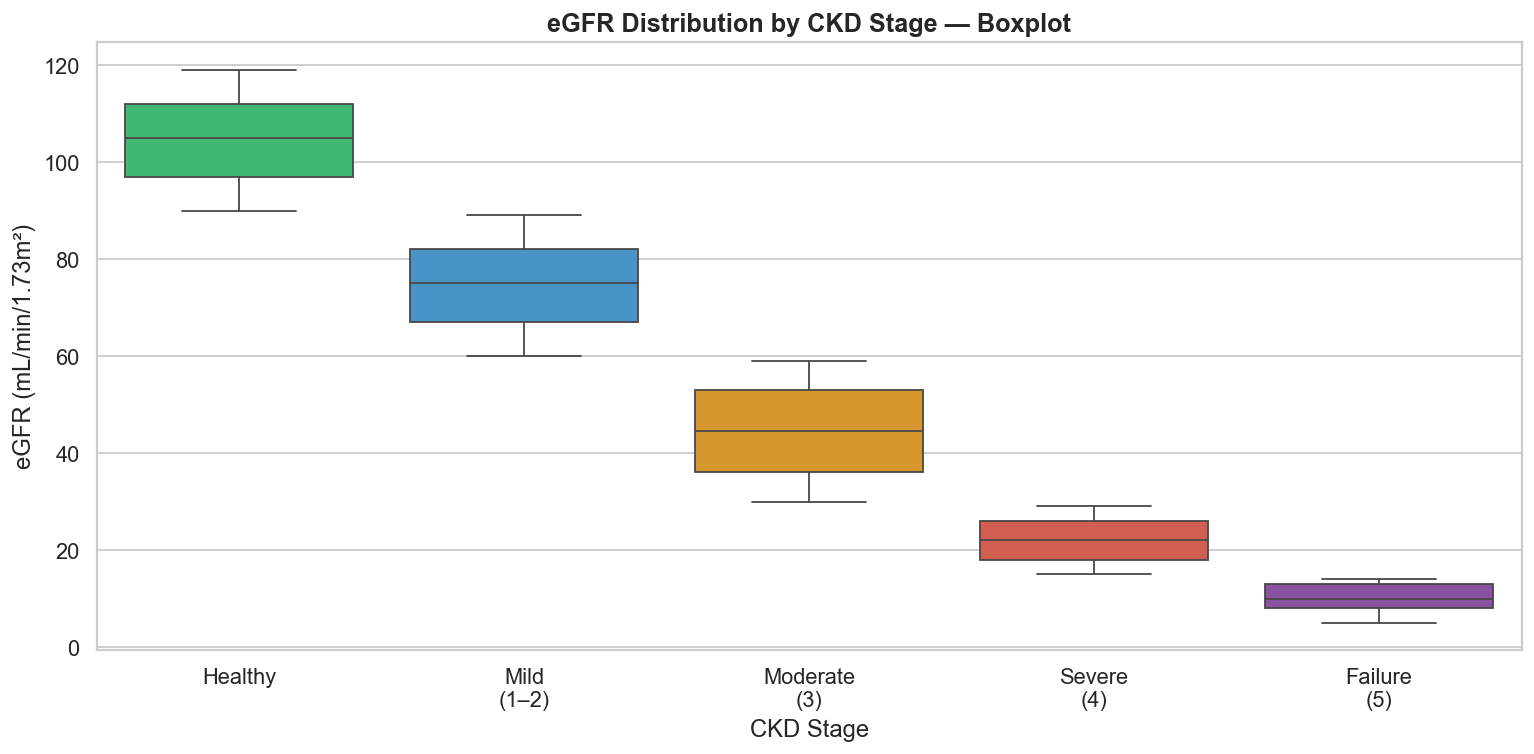

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df, x="Target", y="eGFR",
    order=stage_order,
    palette=list(stage_palette.values()),
    flierprops=dict(marker="o", markerfacecolor="gray", markersize=3, alpha=0.4),
    ax=ax
)

ax.set_xticklabels(["Healthy", "Mild\n(1–2)", "Moderate\n(3)", "Severe\n(4)", "Failure\n(5)"])
ax.set_title("eGFR Distribution by CKD Stage — Boxplot", fontsize=14, fontweight="bold")
ax.set_xlabel("CKD Stage")
ax.set_ylabel("eGFR (mL/min/1.73m²)")

plt.tight_layout()
plt.savefig("plots/10_boxplot_egfr_stage.png", bbox_inches="tight")
plt.show()

---
## 🗂️ 8. Bonus: Pandas Aggregation on Real Dataset

> Combining Pandas `.groupby()` with NumPy statistics to summarize clinical data by CKD stage.

In [ ]:
# Mean + Std of key vitals grouped by CKD stage
summary = df.groupby("Target")[["Age", "eGFR", "Serum_Creatinine", "BMI", "Hemoglobin"]].agg(
    ["mean", "std", "median"]
).round(2)

# Reorder rows by stage severity
summary = summary.reindex(stage_order)
summary

### 8.1 — Heatmap: Mean eGFR & Creatinine by Stage

In [ ]:
heat_data = df.groupby("Target")[
    ["eGFR", "Serum_Creatinine", "Hemoglobin", "BMI", "Age"]
].mean().reindex(stage_order).round(2)

# Normalize each column to [0,1] for color comparison
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heat_norm, annot=heat_data, fmt=".1f", cmap="RdYlGn",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Normalized Value"})

ax.set_yticklabels(["Healthy", "Mild (1–2)", "Moderate (3)", "Severe (4)", "Failure (5)"],
                   rotation=0)
ax.set_title("Clinical Feature Means by CKD Stage (Heatmap)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("plots/11_heatmap_stage_features.png", bbox_inches="tight")
plt.show()

---
## ✅ 9. Summary

| Topic | What We Did | NumPy / Seaborn Function |
|---|---|---|
| NumPy basics | Arrays from dataset columns | `np.array`, `np.mean`, `np.std`, `np.median` |
| Line plot | Age profile + mean/median lines | `matplotlib` |
| Bar chart | Mean vs Median comparison | `ax.bar` |
| Scatter plot | Age vs eGFR by CKD stage | `ax.scatter` + trend line |
| Variance & Std Dev | Per-feature spread analysis | `np.var`, `np.std` |
| Error band line plot | Mean ± Std Dev per stage | `ax.errorbar` |
| Histogram | Age frequency distribution | `ax.hist`, `sns.histplot` |
| KDE plot | eGFR density by stage | `sns.kdeplot` |
| Percentile & IQR | Q1, Q3, fences, outlier count | `np.percentile` |
| Boxplot | Outliers + spread visualization | `sns.boxplot` |
| Pandas aggregation | GroupBy + multi-stat summary | `.groupby().agg()` |
| Heatmap | Cross-stage feature comparison | `sns.heatmap` |

---

> 📁 All plot images saved to `plots/` directory.  
> 🧠 This notebook demonstrates a complete descriptive statistics workflow on real medical data.